# 01 — E-Perf-2: Latency CDF Comparison (WAFER vs Native vs eKuiper)

> **SHAKEDOWN-MACOS — INFORMATIONAL ONLY.** Numbers below are from macOS
> Apple Silicon shakedown runs. They are NOT thesis-grade canonical results.

Pipeline A at 1000 msg/s. Overlays CDF curves per system.
Reports HDR percentiles (p50, p95, p99, p999).

Produces **Figure 1** (latency CDF comparison).

In [1]:
import json
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

result_dirs = sorted(glob.glob('../../results/e-perf-2/shakedown-macos-*'))
if not result_dirs:
    raise FileNotFoundError('No E-Perf-2 results found')
RESULT_DIR = result_dirs[-1]
print(f'Using: {RESULT_DIR}')

Using: ../../results/e-perf-2/shakedown-macos-2026-07-22T19-38-10Z


In [2]:
def load_latency_percentiles(system):
    """Load per-run percentile data from subscriber-metadata.json."""
    runs = sorted(glob.glob(f'{RESULT_DIR}/{system}/run-*'))
    records = []
    for run_dir in runs:
        meta_path = os.path.join(run_dir, 'subscriber-metadata.json')
        if not os.path.exists(meta_path):
            continue
        with open(meta_path) as f:
            d = json.load(f)
        records.append({
            'system': system,
            'min_ns': d.get('latency_min_ns', 0),
            'p50_ns': d.get('latency_p50_ns', 0),
            'p95_ns': d.get('latency_p95_ns', 0),
            'p99_ns': d.get('latency_p99_ns', 0),
            'p999_ns': d.get('latency_p999_ns', 0),
            'mean_ns': d.get('latency_mean_ns', 0),
            'max_ns': d.get('latency_max_ns', 0),
        })
    return pd.DataFrame(records)

wafer_df = load_latency_percentiles('wafer')
native_df = load_latency_percentiles('native')
ekuiper_df = load_latency_percentiles('ekuiper')
print(f'Loaded: wafer={len(wafer_df)}, native={len(native_df)}, ekuiper={len(ekuiper_df)}')

Loaded: wafer=30, native=30, ekuiper=29


In [3]:
# Median percentiles across runs
percentiles = ['p50_ns', 'p95_ns', 'p99_ns', 'p999_ns']
labels = ['p50', 'p95', 'p99', 'p999']

print('=== Latency Percentiles (median across runs, microseconds) ===')
print(f"{'':12} {'p50':>8} {'p95':>8} {'p99':>8} {'p999':>8}")
for name, df in [('WAFER', wafer_df), ('Native', native_df), ('eKuiper', ekuiper_df)]:
    vals = [df[p].median() / 1000 for p in percentiles]
    print(f'{name:12} {vals[0]:8.1f} {vals[1]:8.1f} {vals[2]:8.1f} {vals[3]:8.1f}')

=== Latency Percentiles (median across runs, microseconds) ===
                  p50      p95      p99     p999
WAFER          1314.3   3661.8  13340.7  19324.9
Native         1230.3   1750.0   6684.7  10346.5
eKuiper        1113.1   1580.0   5783.6  12869.6


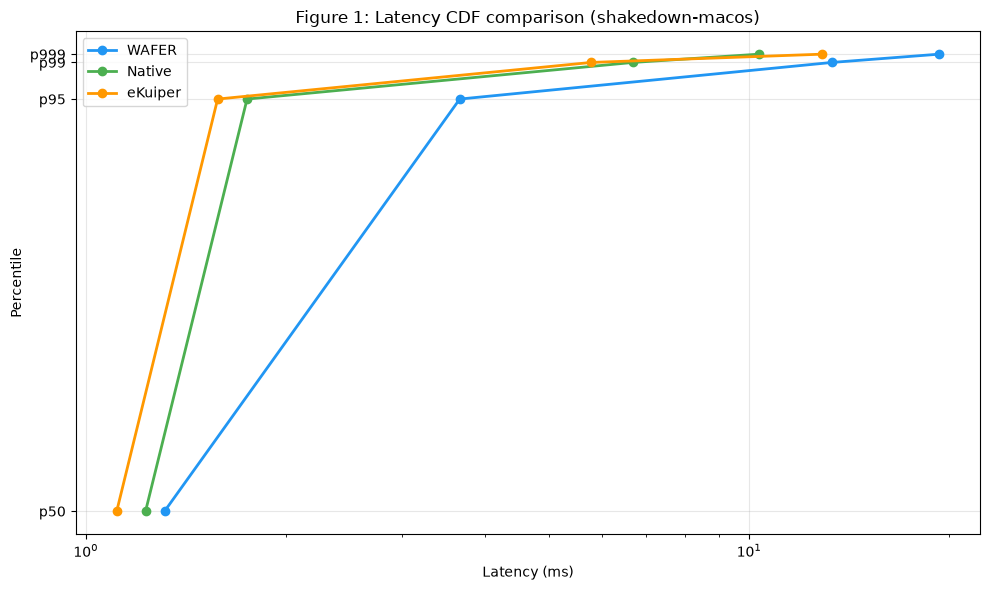

In [4]:
# Simulated CDF from percentile data (approximate)
fig, ax = plt.subplots(figsize=(10, 6))

systems_data = [
    ('WAFER', wafer_df, '#2196F3'),
    ('Native', native_df, '#4CAF50'),
    ('eKuiper', ekuiper_df, '#FF9800'),
]

cdf_points = [0.5, 0.95, 0.99, 0.999]

for name, df, color in systems_data:
    medians = [df[p].median() / 1e6 for p in percentiles]  # convert to ms
    ax.plot(medians, cdf_points, 'o-', color=color, label=name, linewidth=2, markersize=6)

ax.set_xlabel('Latency (ms)')
ax.set_ylabel('Percentile')
ax.set_title('Figure 1: Latency CDF comparison (shakedown-macos)')
ax.legend()
ax.set_yticks(cdf_points)
ax.set_yticklabels(['p50', 'p95', 'p99', 'p999'])
ax.grid(True, alpha=0.3)
ax.set_xscale('log')

plt.tight_layout()
plt.savefig('../../results/e-perf-2/latency-cdf-comparison.png', dpi=150, bbox_inches='tight')
plt.show()